# Importando librerias

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

df_nuevo = pd.read_csv('jobs_cleaned_table.csv', sep=';',encoding='latin1')
conn = sqlite3.connect('jobs.db')
df_nuevo.to_sql('jobs_cleaned_table', conn, if_exists='replace', index=False)
conn.close()

# Cargando Dataset

In [2]:
conn = sqlite3.connect('jobs.db')

query = "SELECT * FROM jobs_cleaned_table WHERE (job_group='Data Scientist' OR job_group='Data Analyst' OR job_group='Data Engineer' or job_group='Business Intelligence')"
df = pd.read_sql_query(query,conn)

df['date_posted'] = pd.to_datetime(df['date_posted'].str.split().str[0], errors='coerce').dt.strftime('%Y-%m-%d')

conn.close()

# EDA inicial

In [3]:
df.head()

,site,title,company,date_posted,job_type,skills,level,job_group,workplace,city,state,country,city_state,experience,education,programming_languages,languages
0,indeed,Business Intelligence Developer / Analyst - Re...,Bluelight Consulting,2026-08-03,fulltime,"CSS, JavaScript, Agile, React, SSIS, SQL, DAX,...",Mid-Level,Business Intelligence,Remote,Cusco,CUS,PE,"Cusco,CUS",2,Bachelor,"SQL, R, JavaScript, CSS, DAX",English
1,indeed,Senior Business Intelligence,Bluelight Consulting,2026-08-03,fulltime,"Python, SQL, Looker, Excel, Power BI",Senior,Business Intelligence,Remote,Lima,LIM,PE,"Lima,LIM",0,Bachelor,"Python, SQL",English
2,indeed,Senior Data Engineer (Celonis / Microsoft Fabr...,Bertoni Solutions,2026-06-03,fulltime,"SQL, ERP, Fabric, Power BI, , Azure",Senior,Data Engineer,Hybrid,Santiago de Surco,LIM,PE,"Santiago de Surco,LIM",5,Bachelor,SQL,"Spanish, English"
3,indeed,3PL Logistics Data Analyst (Remote) | LATAM,HireHawk,2026-05-03,fulltime,"Excel,SQL,Power BI,Data Visualization",Mid-Level,Data Analyst,Remote,Lima,LIM,PE,"Lima,LIM",5,Bachelor,None,English
4,indeed,SSC Master Data / Pre-Qualification Analyst,Millicom,2026-05-03,fulltime,"Agile, Excel, Power BI, , Master",Mid-Level,Data Analyst,Hybrid,El Salvador,LIM,PE,"El Salvador,LLI",2,Master,None,"Spanish, English"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   site                   322 non-null    object
 1   title                  322 non-null    object
 2   company                322 non-null    object
 3   date_posted            195 non-null    object
 4   job_type               322 non-null    object
 5   skills                 322 non-null    object
 6   level                  322 non-null    object
 7   job_group              322 non-null    object
 8   workplace              322 non-null    object
 9   city                   322 non-null    object
 10  state                  322 non-null    object
 11  country                322 non-null    object
 12  city_state             322 non-null    object
 13  experience             322 non-null    int64 
 14  education              322 non-null    object
 15  programming_languages  

In [5]:
df.describe(include='all')

,site,title,company,date_posted,job_type,skills,level,job_group,workplace,city,state,country,city_state,experience,education,programming_languages,languages
count,322,322,322,195,322,322,322,322,322,322,322,322,322,322.000000,322,151,322
unique,2,253,174,24,1,44,4,4,3,34,16,1,50,NaN,3,7,3
top,linkedin,Data Engineer,Inetum,2026-12-03,fulltime,"SQL,Excel,Power BI,Data Visualization",Mid-Level,Data Analyst,On Site,Lima,LIM,PE,"Lima, Peru",NaN,Bachelor,"Python, SQL",Spanish
freq,185,8,16,25,322,51,225,162,149,200,294,322,111,NaN,291,74,149
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.652174,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.320868,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,NaN,NaN


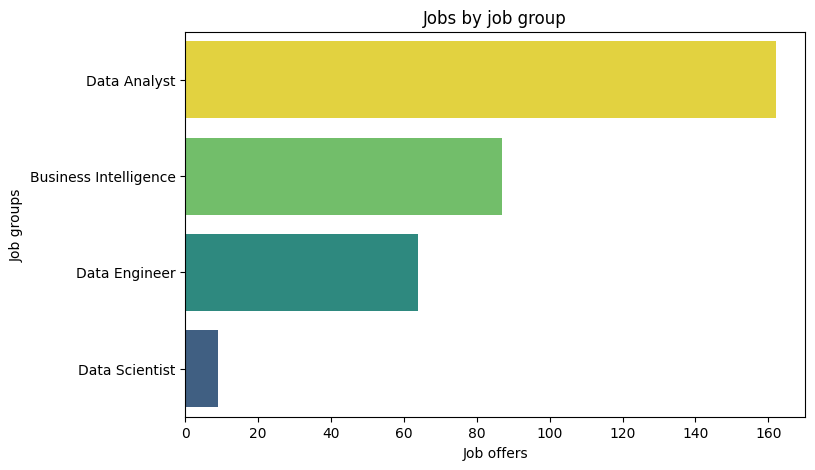

In [6]:
job_groups_counts = df['job_group'].value_counts()

def plot_bars(x,y,figsize=(8,5),title=None,xlabel=(None),ylabel=(None),palette=None):

    plt.figure(figsize=figsize)
    cmap = plt.cm.get_cmap(palette).reversed()
    palette = [cmap(x) for x in np.linspace(0,0.7,len(job_groups_counts))]

    sns.barplot(x=x,y=y,palette=palette)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

plot_bars(x=job_groups_counts.values,y=job_groups_counts.index,title='Jobs by job group',xlabel='Job offers',ylabel='Job groups',palette='viridis')

# Análisis exploratorio de datos

## Lugar

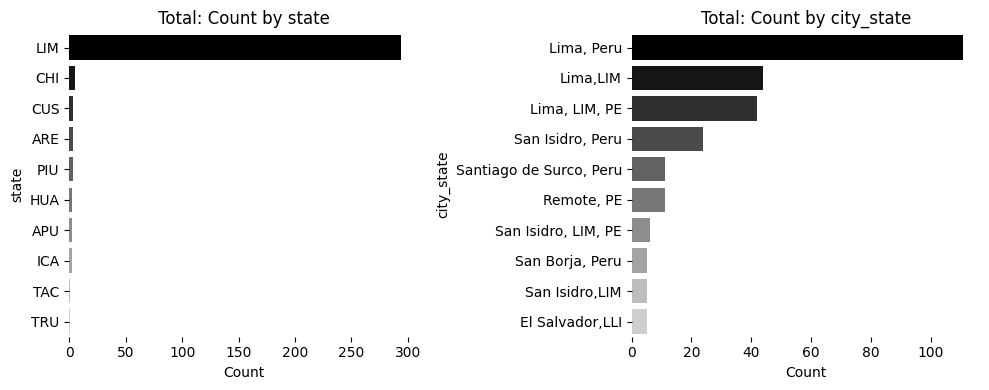

In [7]:
import sqlite3

def plot_multiple_bars(columns,category=None,figsize=(10,12),count_percentage=False,x_y=False,top_10=False,list_values=False,aggregate_column=None):

    rows = df[category].unique() if category is not None else ['Total']
    n_rows, n_cols = len(rows), len(columns)

    fig, axes = plt.subplots(n_rows,n_cols,figsize=figsize,squeeze=False)

    category_palettes = {
        'Data Analyst': 'Blues',
        'Data Engineer': 'Reds',
        'Data Scientist': 'Greens',
        'Business Intelligence': 'Purples',
    }

    for i, row in enumerate(rows):
        group_data = df[df[category] == row] if category is not None else df

        for j, column in enumerate(columns):

            if aggregate_column is None:
                if top_10 and list_values is False:
                    column_top = group_data[column].value_counts().head(10)
            
                elif list_values is not False and top_10 is None:
                    column_top=(group_data[column].str.split(', ').explode()
                                .value_counts()
                                .dropna()
                                .sort_values(ascending=False))
                    column_top = column_top.drop(labels='',errors='ignore')
                
                elif list_values is not False and top_10 is not None:
                    column_top=(group_data[column].str.split(', ').explode()
                                .value_counts()
                                .dropna()
                                .sort_values(ascending=False).head(10))
                    column_top = column_top.drop(labels='',errors='ignore')
                
                else:
                    column_top = group_data[column].value_counts()
            
            else:
                grouped =(
                    group_data.explode(column)
                    .groupby(column)[aggregate_column]
                    .mean()
                    .sort_values(ascending=False)
                )

                if list_values:
                    group_data = group_data.reset_index(drop=True)
                    grouped = pd.DataFrame({
                        column: group_data[column].str.split(', ').explode(),
                        aggregate_column: group_data[aggregate_column]
                    })
                    grouped = grouped.groupby(column)[aggregate_column].mean().sort_values(ascending=False)

                if '' in grouped.index:
                    grouped = grouped.drop('')
                
                column_top = grouped.head(10) if top_10 else grouped

            ax = axes[i,j]
            total = group_data[column].count()

            for spine in ax.spines.values():
                spine.set_visible(False)

            if category is not None:
                palette = category_palettes.get(row,'Blues')
                cmap = plt.cm.get_cmap(palette).reversed()
                palette = [cmap(x) for x in np.linspace(0,0.7,len(column_top))]

            else:
                cmap = plt.cm.get_cmap('Greys').reversed()
                palette = [cmap(x) for x in np.linspace(0,0.7,len(column_top))]

            kwargs ={
                'y':column_top.values,
                'x':column_top.index
            } if x_y else {
                'x':column_top.values,
                'y':column_top.index
            }

            sns.barplot(ax=ax,palette=palette, **kwargs)

            aggregate_label = 'Count' if aggregate_column is None else f'Avg{aggregate_column}'
            ax.set_title(f'{row}: {aggregate_label} by {column}')
            ax.set_xlabel(aggregate_label if not x_y else column)
            ax.set_ylabel(column if not x_y else aggregate_label)

            if count_percentage:
                for k, value in enumerate(column_top.values):
                    percentage = value/total*100
                    annotation_kwargs = {
                        'text': f'{value:.1f}({percentage:.1f}%)',
                        'xy':(k, value) if x_y else (value,k),
                        'xytext': (-30,5) if x_y else (5,0),
                        'textcoords': 'offset points',
                        'va':'center',
                        'ha':'left',
                        'fontsize':10,
                        'color':'black'
                    }
                    ax.annotate(**annotation_kwargs)
            
    plt.tight_layout()
    plt.show()

columns_location = ['state','city_state']

plot_multiple_bars(columns_location,figsize=(10,4),top_10=True)           


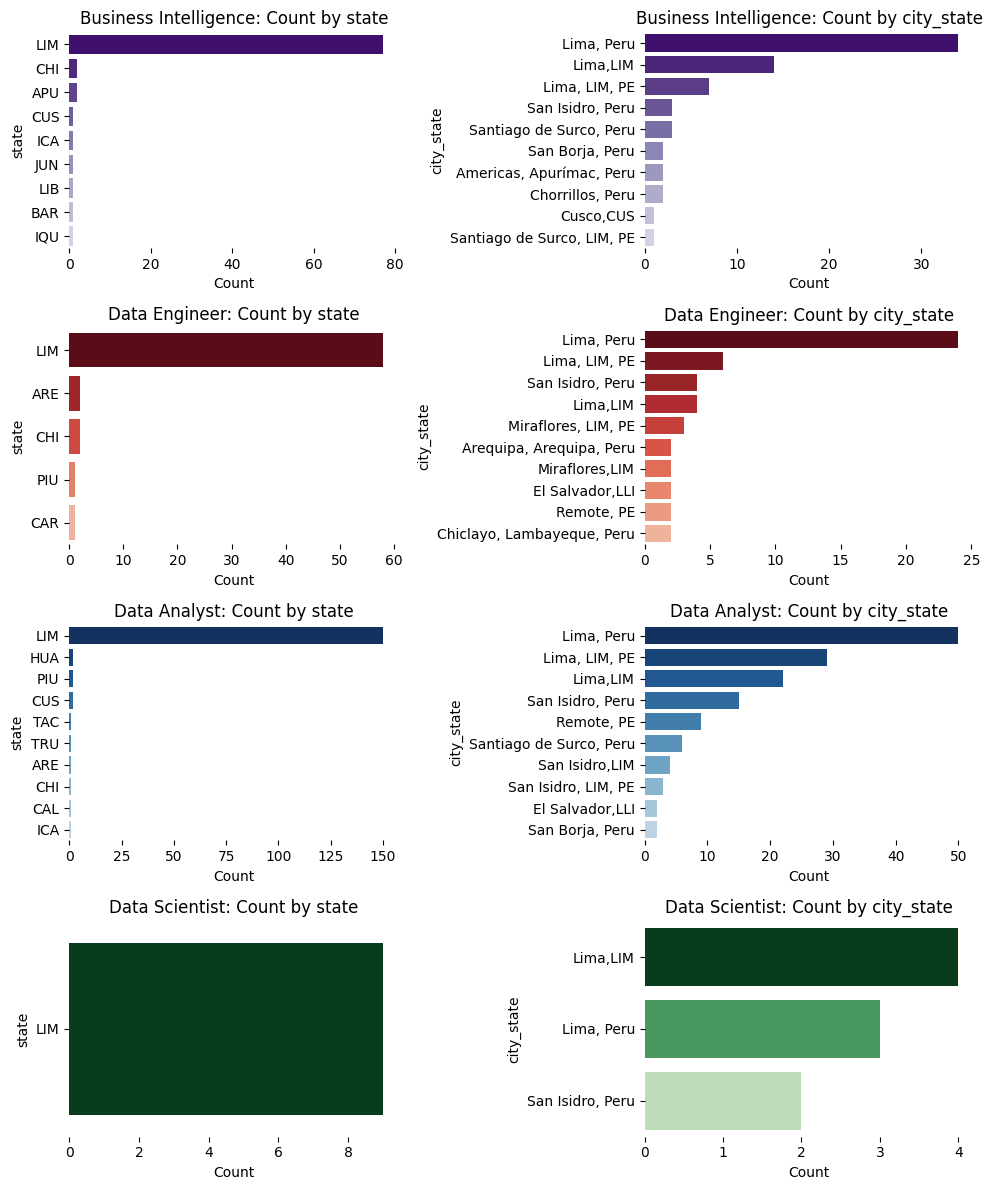

In [8]:
plot_multiple_bars(columns_location,category='job_group',figsize=(10,12),top_10=True)

## Niveles

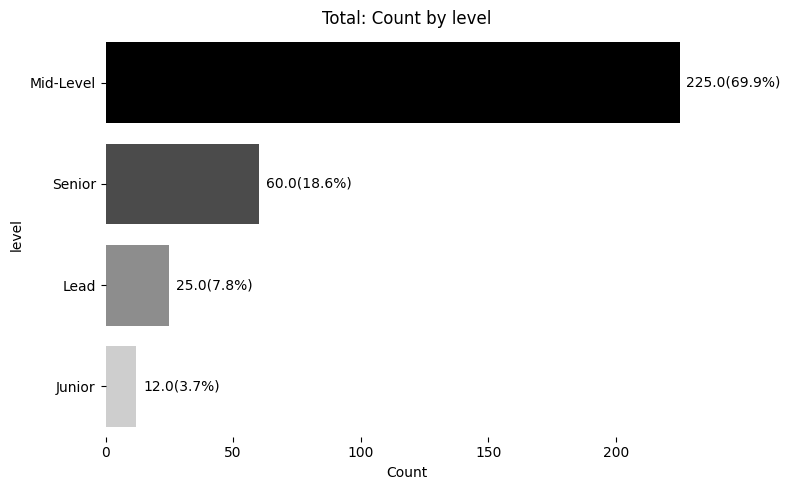

In [9]:
columns_level = ('level',)

plot_multiple_bars(columns_level,figsize=(8,5),count_percentage=True) 

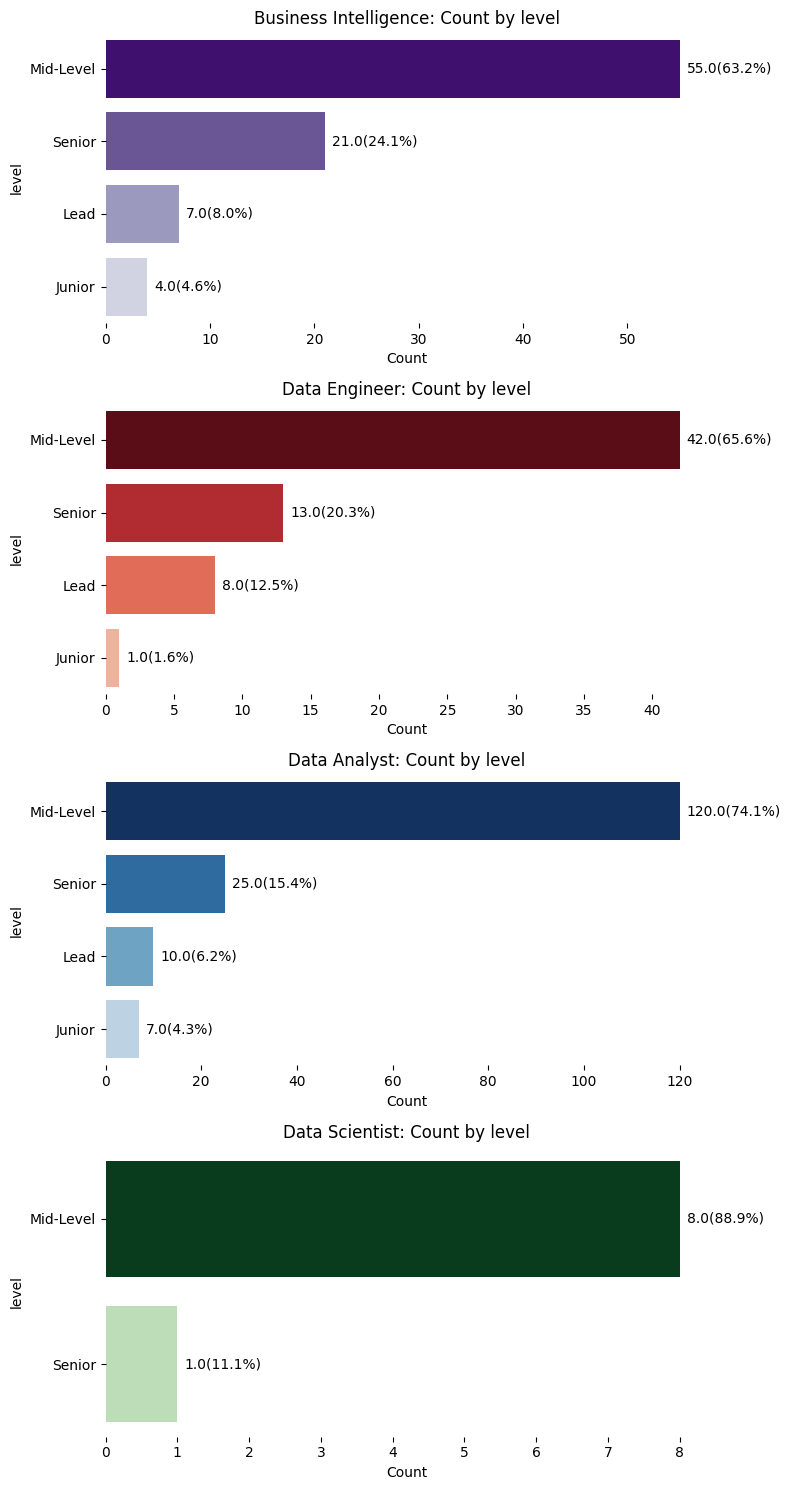

In [10]:
plot_multiple_bars(columns_level,category='job_group',figsize=(8,15),count_percentage=True)

## Experiencia

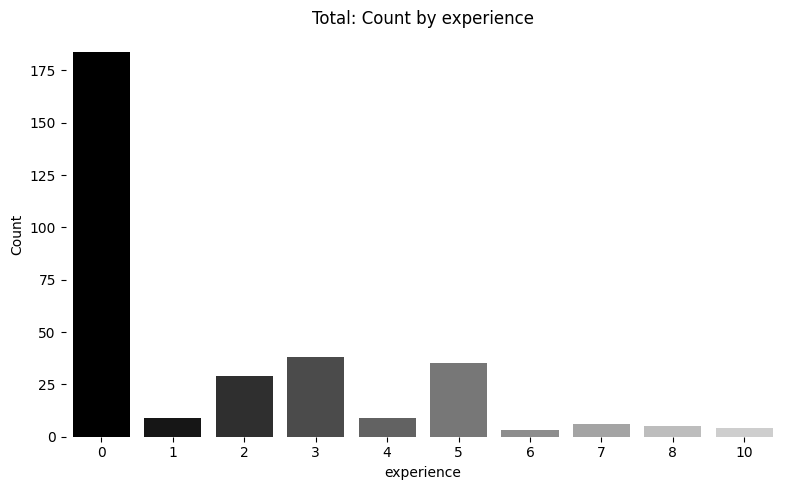

In [11]:
columns_experience = ('experience',)

plot_multiple_bars(columns_experience,figsize=(8,5),x_y=True)

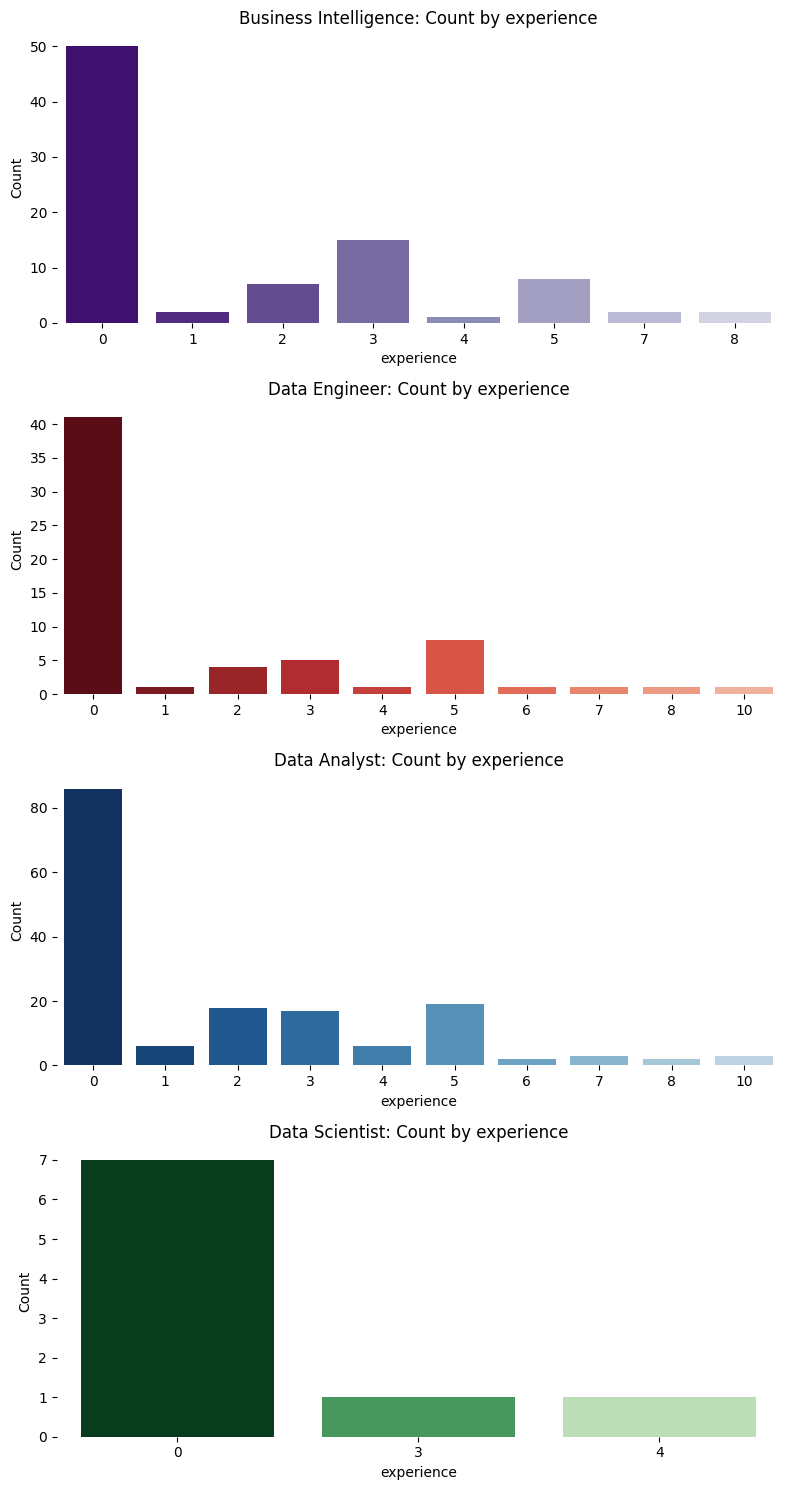

In [12]:
plot_multiple_bars(columns_experience,category='job_group',figsize=(8,15),x_y=True)

## Grado de educación

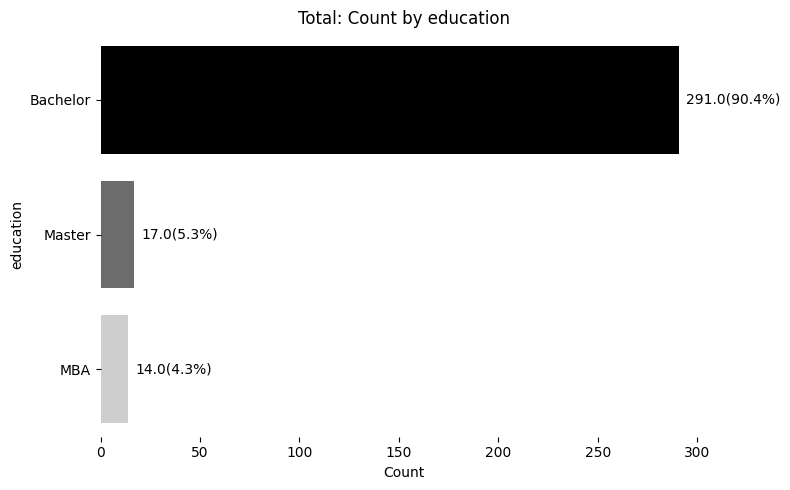

In [13]:
columns_education = ('education',)

plot_multiple_bars(columns_education,figsize=(8,5),count_percentage=True)

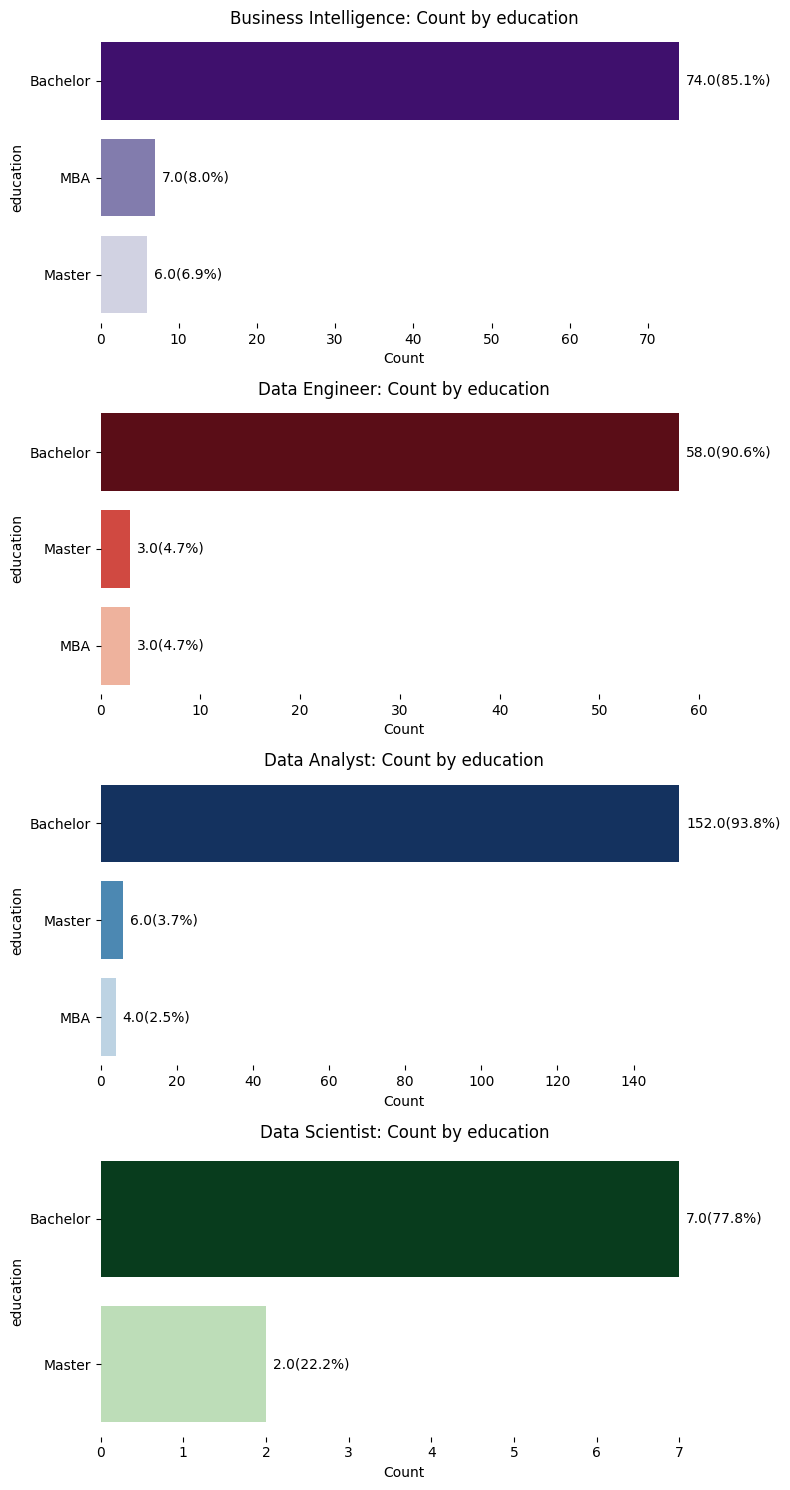

In [14]:
plot_multiple_bars(columns_education,category='job_group',figsize=(8,15),count_percentage=True)

## Habilidades

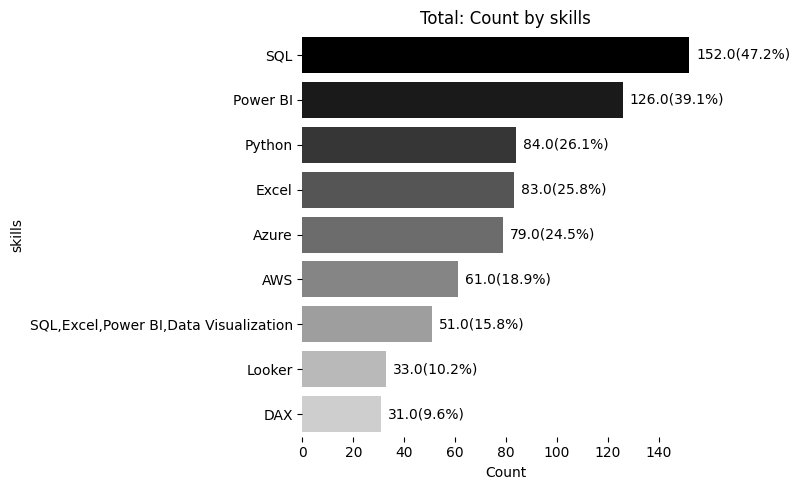

In [15]:
columns_skills = ['skills',]

plot_multiple_bars(columns_skills,figsize=(8,5),list_values=True,count_percentage=True)

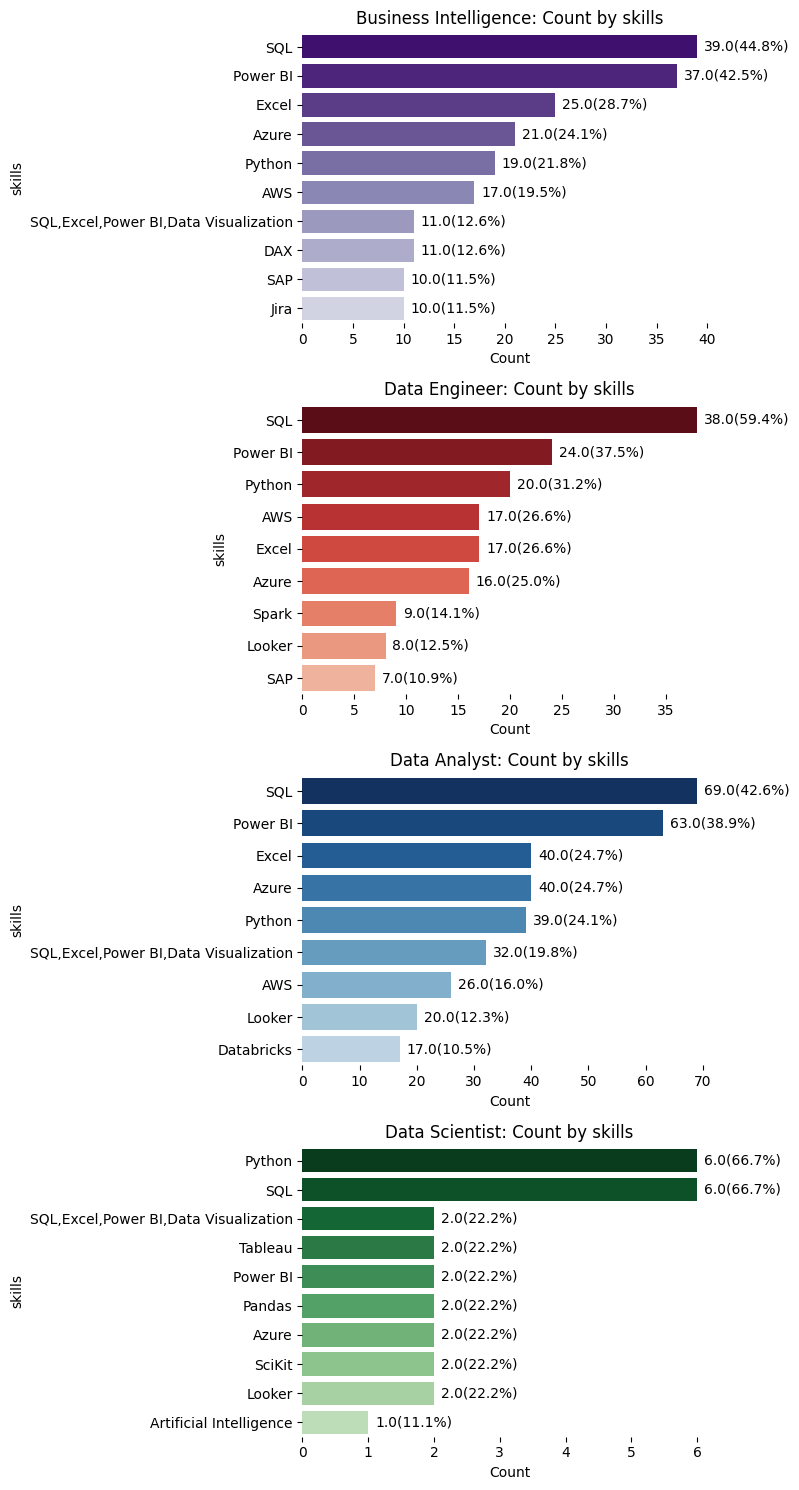

In [16]:
plot_multiple_bars(columns_skills,category='job_group',figsize=(8,15),list_values=True,count_percentage=True)

## Lenguajes de programación

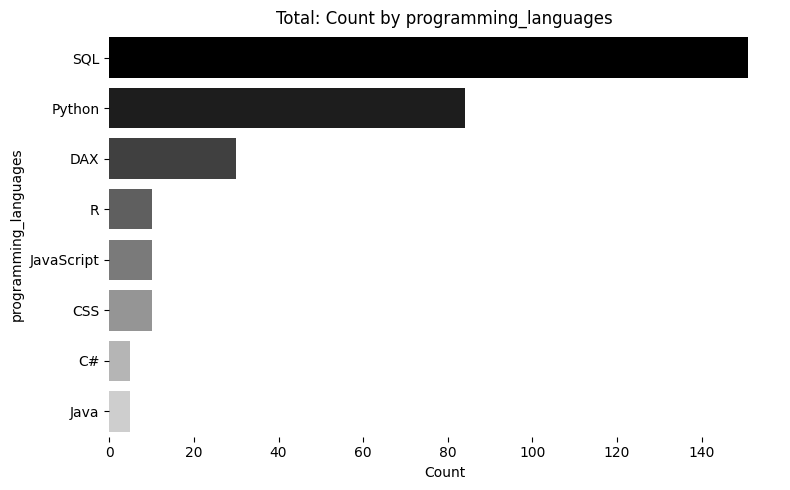

In [17]:
column_programming_language = ('programming_languages',)

plot_multiple_bars(column_programming_language,list_values=True,top_10=True,figsize=(8,5))

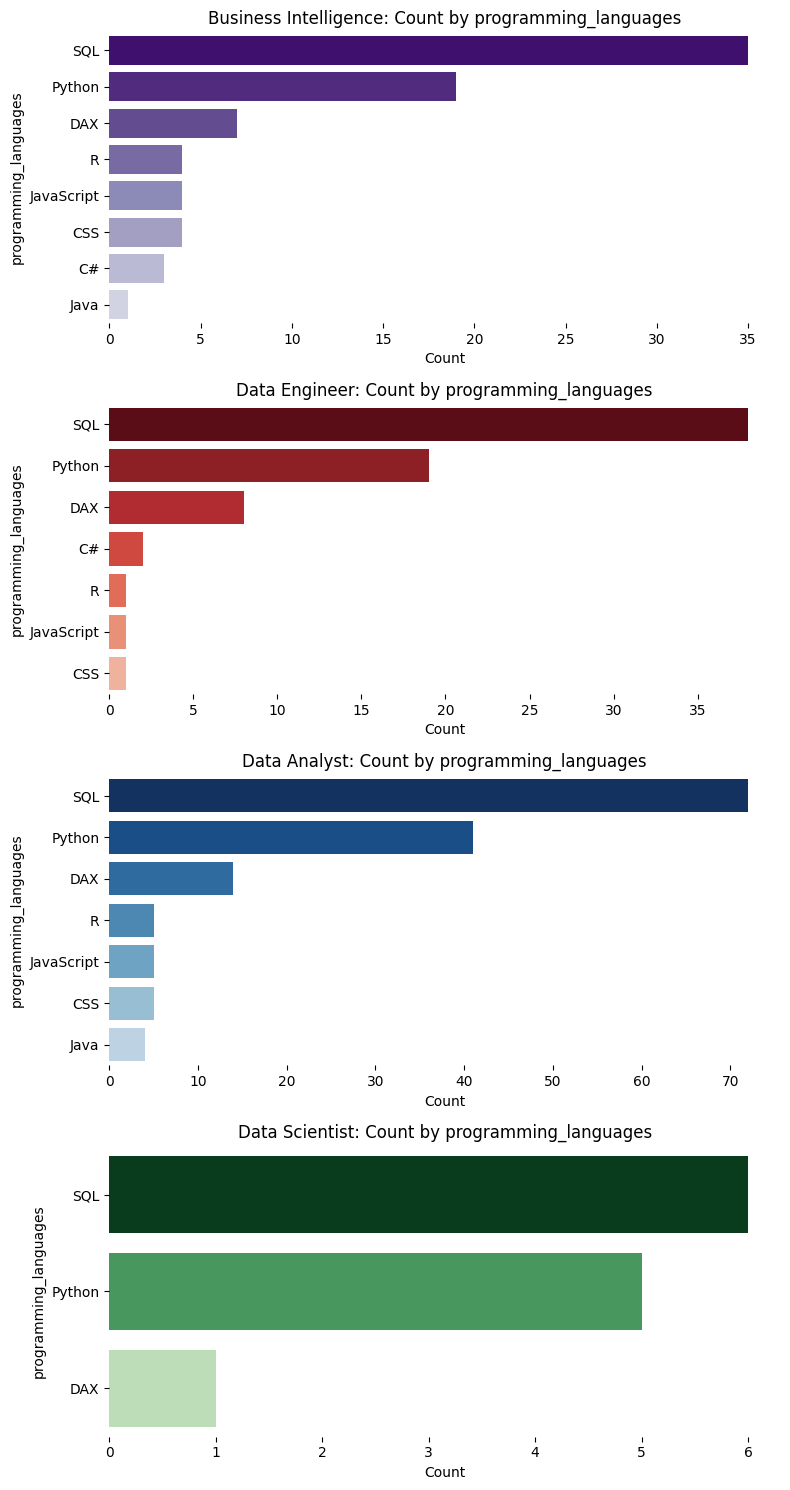

In [18]:
plot_multiple_bars(column_programming_language,category='job_group',list_values=True,top_10=True,figsize=(8,15))

## Idiomas mejor pagados

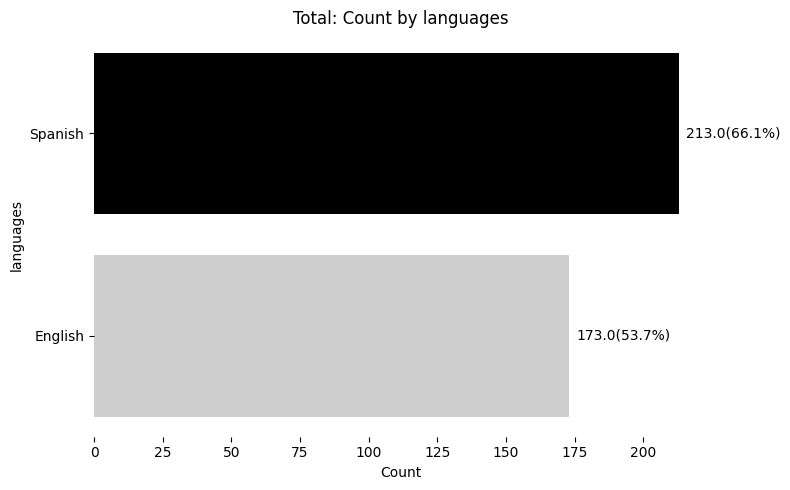

In [19]:
column_languages = ('languages',)

plot_multiple_bars(column_languages,list_values=True,figsize=(8,5),count_percentage=True)

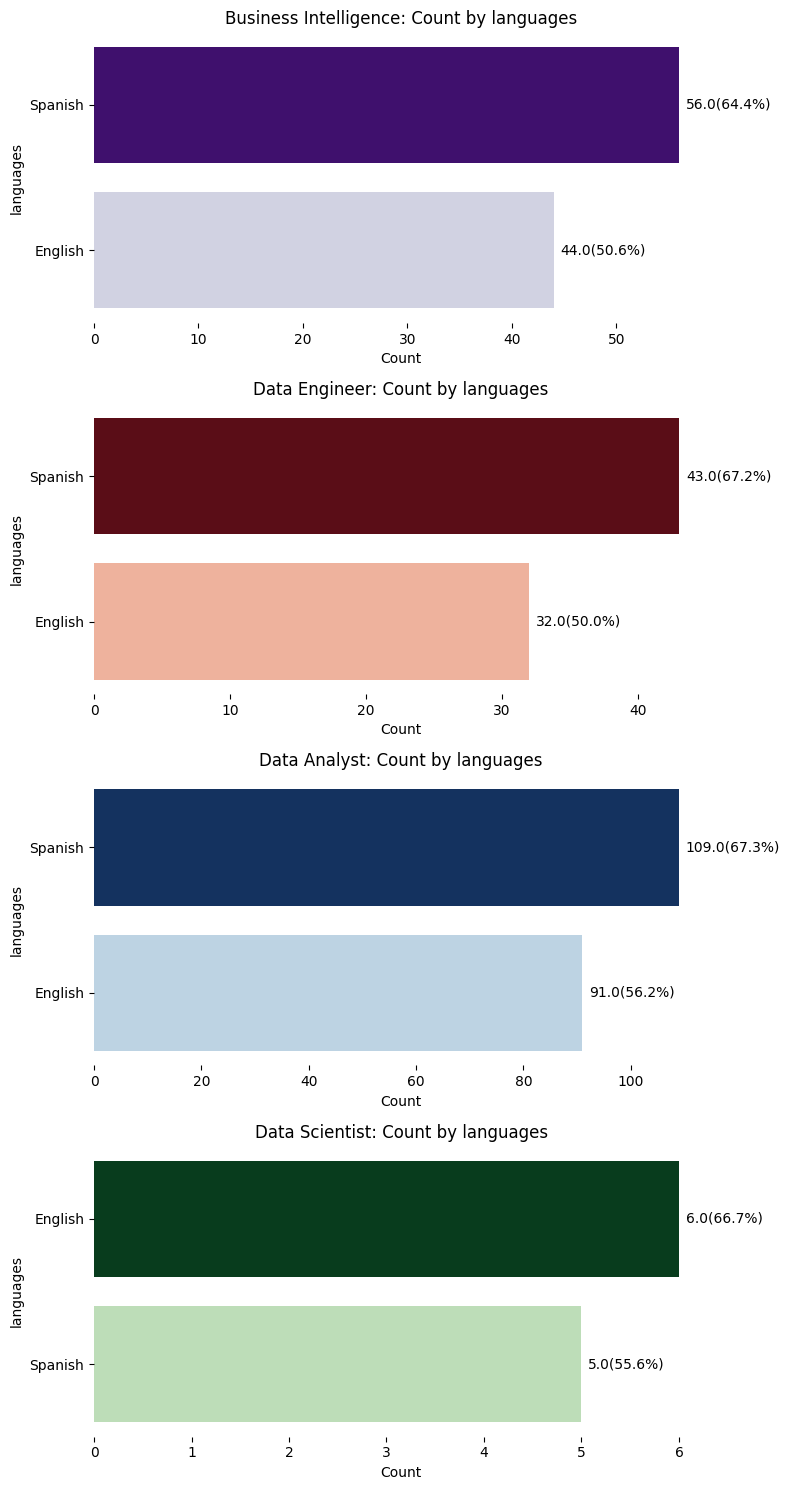

In [20]:
plot_multiple_bars(column_languages,category = 'job_group',list_values=True,figsize=(8,15),count_percentage=True)

# Modalidad de trabajo

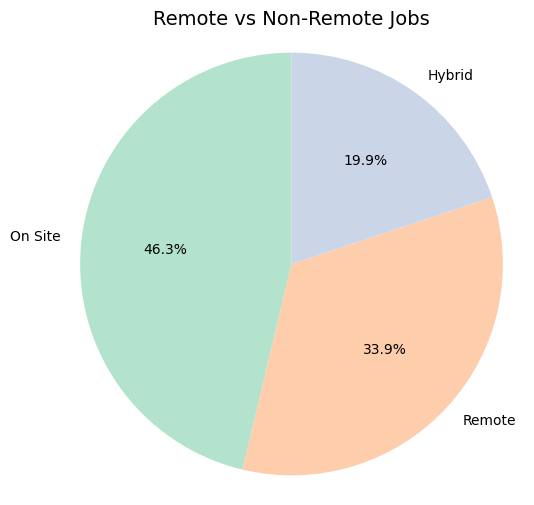

In [21]:
def plot_remote_distribution(df,column_name,title,category=None,figsize=(6,6)):

    def create_pie(data,chart_title,ax):
        counts = data.value_counts()
        ax.pie(
            counts,
            labels=counts.index,
            autopct='%1.1f%%',
            colors=plt.cm.Pastel2.colors,
            startangle=90
        )
        ax.set_title(chart_title,fontsize=14)
        ax.axis('equal')
    
    if category:
        unique_categories = df[category].unique()
        n_categories = len(unique_categories)

        fig,axes = plt.subplots(n_categories,1,figsize=figsize)
        if n_categories == 1:
            axes = [axes]

        for i, job_group in enumerate(unique_categories):
            df_grouped = df[df[category] == job_group]
            title_grouped = f"{job_group}:{title}"
            create_pie(df_grouped[column_name], title_grouped, axes[i])

        plt.tight_layout()
        plt.show()

    else:

        fig, ax = plt.subplots(figsize=figsize)
        create_pie(df[column_name],title,ax)
        plt.show()

plot_remote_distribution(df=df,column_name='workplace',title='Remote vs Non-Remote Jobs')

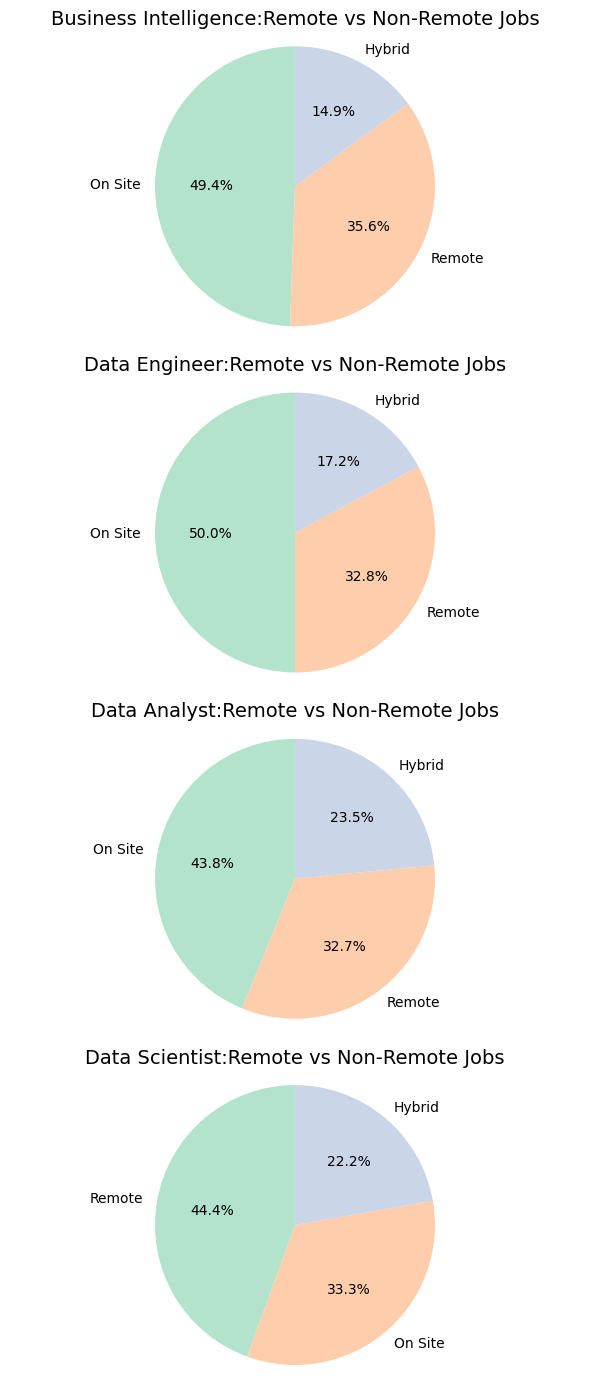

In [22]:
plot_remote_distribution(df=df,column_name='workplace',title='Remote vs Non-Remote Jobs', figsize=(6,14),category='job_group')